# Comparativa

Archivo aparte para no confundirse y lanzar las celdas que tardan (por eso los logs)

Mini crossval

DQN mejor lr = 6e-04 (reward = 63.6)
PPO mejor lr = 6e-04 (reward = 13.3)
A2C mejor lr = 5e-04 (reward = 59.2)


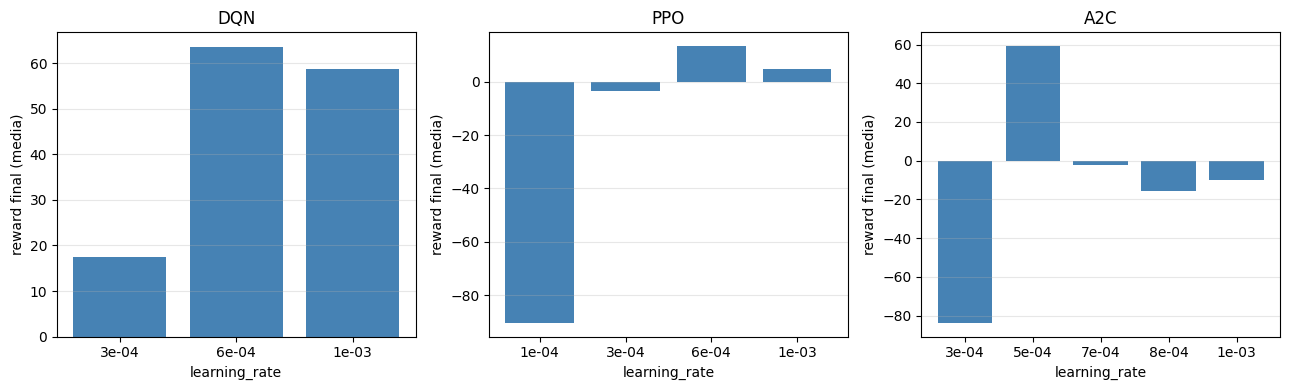

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ALGOS = ["dqn", "ppo", "a2c"]

def reward_final(run_dir, last_n=20):
    csv = os.path.join(run_dir, "train.monitor.csv")
    if not os.path.exists(csv):
        return None
    df = pd.read_csv(csv, skiprows=1)
    return df["r"].tail(last_n).mean()

fig, axes = plt.subplots(1, len(ALGOS), figsize=(13, 4))
for ax, algo in zip(axes, ALGOS):
    sweep_dir = f"logs_{algo}_sweep"
    if not os.path.isdir(sweep_dir):
        ax.set_title(f"{algo.upper()} (sin datos)")
        ax.axis("off")
        continue
    rows = []
    for run in sorted(os.listdir(sweep_dir)):
        m = re.match(r"lr([0-9.e+-]+)_s(\d+)", run)
        if not m:
            continue
        lr, seed = float(m.group(1)), int(m.group(2))
        r = reward_final(os.path.join(sweep_dir, run))
        if r is not None:
            rows.append({"lr": lr, "seed": seed, "reward": r})
    if not rows:
        ax.set_title(f"{algo.upper()} (vacio)")
        continue
    df = pd.DataFrame(rows)
    media = df.groupby("lr")["reward"].mean().sort_index()
    ax.bar([f"{lr:.0e}" for lr in media.index], media.values, color="steelblue")
    ax.set_title(f"{algo.upper()}")
    ax.set_xlabel("learning_rate")
    ax.set_ylabel("reward final (media)")
    ax.grid(alpha=0.3, axis="y")
    mejor_lr = media.idxmax()
    print(f"{algo.upper()} mejor lr = {mejor_lr:.0e} (reward = {media[mejor_lr]:.1f})")

plt.tight_layout()

plt.savefig("comparativa_learning_rates", dpi=300)

plt.show()

Modelos finales aprendizaje

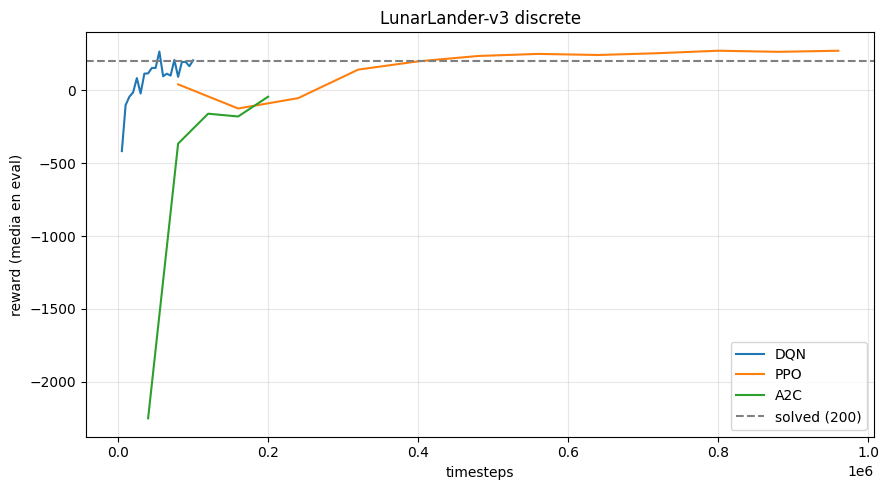

In [2]:
logs = {"DQN": "logs_dqn", "PPO": "logs_ppo", "A2C": "logs_a2c"}

plt.figure(figsize=(9, 5))
for nombre, log_dir in logs.items():
    eval_path = f"{log_dir}/eval/evaluations.npz"
    if not os.path.exists(eval_path):
        print(f"falta {eval_path}")
        continue
    d = np.load(eval_path)
    plt.plot(d["timesteps"], d["results"].mean(axis=1), label=nombre)

plt.axhline(200, color="gray", linestyle="--", label="solved (200)")
plt.xlabel("timesteps")
plt.ylabel("reward (media en eval)")
plt.title("LunarLander-v3 discrete")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparativa_curvas_aprendizaje", dpi=300)
plt.show()

In [13]:
import gymnasium as gym
from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.evaluation import evaluate_policy

modelos = [
    ("DQN", DQN, "logs_dqn/dqn_lunarlander"),
    ("PPO", PPO, "logs_ppo/ppo_lunarlander"),
    ("A2C", A2C, "logs_a2c/a2c_lunarlander"),
]

filas = []
for nombre, clase, ruta in modelos:
    if not os.path.exists(ruta + ".zip"):
        print(f"falta {ruta}.zip")
        continue
    env = gym.make("LunarLander-v3")
    modelo = clase.load(ruta)
    m, s = evaluate_policy(modelo, env, n_eval_episodes=20, deterministic=True)
    filas.append({"algoritmo": nombre, "reward": round(m, 1), "std": round(s, 1)})
    env.close()

print(pd.DataFrame(filas).to_string(index=False))

/home/jorge/Escritorio/MASTER/AprendizajeRefuerzo/.venv/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


algoritmo  reward   std
      DQN   226.9  44.8
      PPO   277.3  13.3
      A2C  -167.6 207.8


Grafica final mean +- std

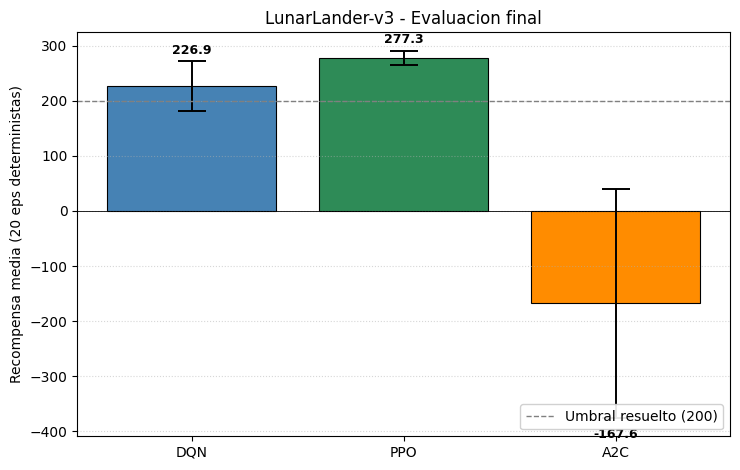

In [14]:
df_eval = pd.DataFrame(filas)
colores = {"DQN": "steelblue", "PPO": "seagreen", "A2C": "darkorange"}

fig, ax = plt.subplots(figsize=(7.5, 4.8))
xs = np.arange(len(df_eval))
ax.bar(
    xs, df_eval["reward"], yerr=df_eval["std"],
    capsize=10, color=[colores.get(a, "gray") for a in df_eval["algoritmo"]],
    edgecolor="black", linewidth=0.8,
    error_kw=dict(elinewidth=1.4, capthick=1.4),
)
ax.axhline(200, ls="--", c="gray", lw=1, label="Umbral resuelto (200)")
ax.axhline(0,   c="black", lw=0.6)

for x, m, s in zip(xs, df_eval["reward"], df_eval["std"]):
    offset = (s + 8) if m >= 0 else -(s + 18)
    ax.text(x, m + offset, f"{m:.1f}", ha="center",
            va="bottom" if m >= 0 else "top",
            fontsize=9, fontweight="bold")

ax.set_xticks(xs)
ax.set_xticklabels(df_eval["algoritmo"])
ax.set_ylabel("Recompensa media (20 eps deterministas)")
ax.set_title("LunarLander-v3 - Evaluacion final")
ax.grid(axis="y", ls=":", alpha=0.5)
ax.legend(loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.savefig("comparativa_eval_final.png", dpi=300)
plt.show()